In [66]:
# A whole new big mess of a step...
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch
import time
import blitz
import blitz.modules
import blitz.utils

In [67]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Model running via: {device}")
time_start = time.time() 


Model running via: cpu


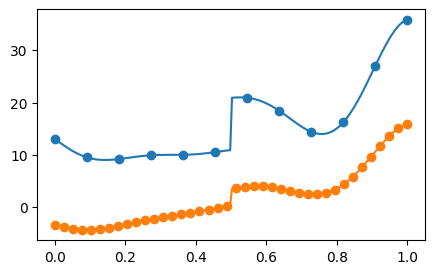

In [68]:
# Globally Shared Model(s) Parameters
lf_num_epochs = 1400
hf_num_epochs = 1500
# Increased MF epochs moderately (was 200) so training improves but stays reasonable for CPU
MF_epochs = 1600
embedding = 2

# NOTE: models expect 7 hidden layers (indices 0..6). Provide a 7-element list for LF/HF.
hidden_dims = [100, 100, 100, 100, 100, 100, 100]
# Give the Multi-Fidelity model slightly more capacity without affecting LF/HF
MF_hidden_dims = [150, 150, 150, 150, 150, 150, 150]

LF_training_size = 40
HF_training_size = 12


def LF(y):
    zeros = torch.zeros_like(y)
    half = torch.ones_like(y) * 0.5
    y_0 = torch.where(y <= half, 0.5 * (6 * y - 2)**2 * torch.sin(12 * y - 4) + 10 * (y - 0.5), zeros)
    y_1 = torch.where(half < y, 3 + 0.5 * (6 * y - 2)**2 * torch.sin(12 * y - 4) + 10 * (y - 0.5), y_0)
    return y_1

def HF(y):
    zeros = torch.zeros_like(y)
    half = torch.ones_like(y) * 0.5
    y_0 = torch.where(y <= half, 2*LF(y) - 20*y + 20, zeros)
    y_1 = torch.where(half < y, 4 + 2*LF(y) - 20*y + 20, y_0)
    return y_1


# Run this through the model to get the black prediction line (predictionu bundan al)
Z = torch.linspace(0, 1, 200)[:,None]  # reduced from 1000 -> 200 for speed

# Model's total training/val/testing dataset
LF_TS = torch.linspace(0, 1, LF_training_size)[:,None]
HF_TS = torch.linspace(0, 1, HF_training_size)[:,None]

# Forming LF Test Sets with a neat trick
X_LF_train, X_LF_test, Y_LF_train, Y_LF_test = train_test_split(LF_TS, LF(LF_TS), test_size=0.8, shuffle=True, random_state=156)
X_HF_train, X_HF_test, Y_HF_train, Y_HF_test = train_test_split(HF_TS, HF(HF_TS), test_size=0.8, shuffle=True, random_state=156)

# Forming the real equally spaced training sets
X_LF_train = LF_TS
Y_LF_train = LF(LF_TS) 

X_HF_train = HF_TS
Y_HF_train = HF(HF_TS)

plt.figure(figsize=(5,3))
plt.plot(Z ,HF(Z))
plt.plot(Z ,LF(Z))
plt.scatter(X_HF_train, Y_HF_train)
plt.scatter(X_LF_train, Y_LF_train)

# Transfering data to GPU for CUDA
X_LF_train = X_LF_train.to(device); Y_LF_train = Y_LF_train.to(device)
X_HF_train = X_HF_train.to(device); Y_HF_train = Y_HF_train.to(device)

X_LF_test = X_LF_test.to(device); Y_LF_test = Y_LF_test.to(device)
X_HF_test = X_HF_test.to(device); Y_HF_test = Y_HF_test.to(device)


Low Fidelity Network

In [ ]:
LF_input_dim = 1
LF_output_dim = 1

@blitz.utils.variational_estimator

class LowFidelityNetwork(torch.nn.Module):
  def __init__(self, hidden_dims, LF_input_dim, LF_output_dim):
    super().__init__()
    self.fc1 = blitz.modules.BayesianLinear(LF_input_dim, hidden_dims[0])
    self.bn1 = nn.LayerNorm(hidden_dims[0])
    self.fc2 = blitz.modules.BayesianLinear(hidden_dims[0], hidden_dims[1])
    self.bn2 = nn.LayerNorm(hidden_dims[1])
    self.fc3 = blitz.modules.BayesianLinear(hidden_dims[1], hidden_dims[2])
    self.bn3 = nn.LayerNorm(hidden_dims[2])
    self.fc4 = blitz.modules.BayesianLinear(hidden_dims[2], hidden_dims[3])
    self.bn4 = nn.LayerNorm(hidden_dims[3])
    self.fc5 = blitz.modules.BayesianLinear(hidden_dims[3], hidden_dims[4])
    self.bn5 = nn.LayerNorm(hidden_dims[4])
    self.fc6 = blitz.modules.BayesianLinear(hidden_dims[4], hidden_dims[5])
    self.bn6 = nn.LayerNorm(hidden_dims[5])
    self.fc7 = blitz.modules.BayesianLinear(hidden_dims[5], hidden_dims[6])
    self.bn7 = nn.LayerNorm(hidden_dims[6])
    self.fcEND = blitz.modules.BayesianLinear(hidden_dims[6], LF_output_dim)

  def forward(self, x):
    x = torch.relu(self.bn1(self.fc1(x)))
    x = torch.relu(self.bn2(self.fc2(x)))
    x = torch.relu(self.bn3(self.fc3(x)))
    x = torch.relu(self.bn4(self.fc4(x)))
    x = torch.relu(self.bn5(self.fc5(x)))
    x = torch.relu(self.bn6(self.fc6(x)))
    x = torch.relu(self.bn7(self.fc7(x)))
    x = self.fcEND(x)
    return x

LF_model = LowFidelityNetwork(hidden_dims, LF_input_dim, LF_output_dim).to(device)

for param in LF_model.parameters():
    param.requires_grad = True

In [70]:
LF_model.train()

# Training
LF_losses = [] 
val_losses = []
LF_loss = torch.zeros(1)

LF_batch_size = 100

# LF_loss criterion and optimizer
criterion = torch.nn.MSELoss().to(device)
optimizer = torch.optim.Adam(LF_model.parameters(), lr=0.0005, weight_decay=1e-6) # weight_decay=1e-5


for epoch in range(lf_num_epochs):
    
    permutation = torch.randperm(X_LF_train.size()[0])
    
    for i in range(0,X_LF_train.size()[0], LF_batch_size):
        optimizer.zero_grad()

        indices = permutation[i:i+LF_batch_size]
        batch_x, batch_y = X_LF_train[indices], Y_LF_train[indices]
    
        LF_loss = LF_model.sample_elbo(inputs=batch_x, labels=batch_y, criterion=criterion, sample_nbr=1)
        LF_losses.append(LF_loss.item())
        LF_loss.backward()
        optimizer.step()

    if (epoch+1) % 600 == 0:
        print(f'Epoch [{epoch+1}/{hf_num_epochs}], Loss: {LF_loss.item():.4f}')

Epoch [600/1500], Loss: 237733.6562
Epoch [1200/1500], Loss: 219010.7188
Epoch [1200/1500], Loss: 219010.7188


Epochs needed (out of 1400): 1400
LF Training Loss: 212993.703125


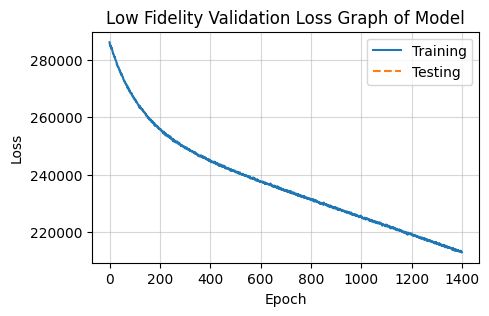

In [71]:
plt.figure(figsize=(5,3))
plt.plot(LF_losses, label = "Training")
plt.xlabel('Epoch')
plt.ylabel('LF_Loss')
plt.title('Low Fidelity Training Loss Graph of Model')

plt.plot(val_losses, "--" , label = "Testing")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Low Fidelity Validation Loss Graph of Model')
plt.grid(which='both', alpha=0.5)
plt.legend(loc='upper right')
# plt.show()

print(f"Epochs needed (out of {lf_num_epochs}): {len(LF_losses)}")
print(f"LF Training Loss: {LF_loss}")

High Fidelity Model

In [ ]:
HF_input_dim = 1
HF_output_dim = 1

@blitz.utils.variational_estimator
class HighFidelityNetwork(torch.nn.Module):
  def __init__(self, hidden_dims, HF_input_dim, HF_output_dim):
    super().__init__()
    self.fc1 = blitz.modules.BayesianLinear(HF_input_dim, hidden_dims[0])
    self.bn1 = nn.LayerNorm(hidden_dims[0])
    self.fc2 = blitz.modules.BayesianLinear(hidden_dims[0], hidden_dims[1])
    self.bn2 = nn.LayerNorm(hidden_dims[1])
    self.fc3 = blitz.modules.BayesianLinear(hidden_dims[1], hidden_dims[2])
    self.bn3 = nn.LayerNorm(hidden_dims[2])
    self.fc4 = blitz.modules.BayesianLinear(hidden_dims[2], hidden_dims[3])
    self.bn4 = nn.LayerNorm(hidden_dims[3])
    self.fc5 = blitz.modules.BayesianLinear(hidden_dims[3], hidden_dims[4])
    self.bn5 = nn.LayerNorm(hidden_dims[4])
    self.fc6 = blitz.modules.BayesianLinear(hidden_dims[4], hidden_dims[5])
    self.bn6 = nn.LayerNorm(hidden_dims[5])
    self.fc7 = blitz.modules.BayesianLinear(hidden_dims[5], hidden_dims[6])
    self.bn7 = nn.LayerNorm(hidden_dims[6])
    self.fcEND = blitz.modules.BayesianLinear(hidden_dims[6], HF_output_dim)

  def forward(self, x):
    x = torch.relu(self.bn1(self.fc1(x)))
    x = torch.relu(self.bn2(self.fc2(x)))
    x = torch.relu(self.bn3(self.fc3(x)))
    x = torch.relu(self.bn4(self.fc4(x)))
    x = torch.relu(self.bn5(self.fc5(x)))
    x = torch.relu(self.bn6(self.fc6(x)))
    x = torch.relu(self.bn7(self.fc7(x)))
    x = self.fcEND(x)
    return x

HF_model = HighFidelityNetwork(hidden_dims, HF_input_dim, HF_output_dim).to(device)

for param in HF_model.parameters():
    param.requires_grad = True

In [73]:
HF_model.train()

# Training
HF_losses = [] 
val_losses = []
HF_loss = torch.zeros(1)

HF_batch_size = 100

# HF_loss criterion and optimizer
criterion = torch.nn.MSELoss().to(device) 
optimizer = torch.optim.Adam(HF_model.parameters(), lr=0.0001, weight_decay=1e-6) # weight_decay=1e-5

for epoch in range(hf_num_epochs):
    
    permutation = torch.randperm(X_HF_train.size()[0])
    
    for i in range(0,X_HF_train.size()[0], HF_batch_size):
        optimizer.zero_grad()

        indices = permutation[i:i+HF_batch_size]
        batch_x, batch_y = X_HF_train[indices], Y_HF_train[indices]
    
        HF_loss = HF_model.sample_elbo(inputs=batch_x, labels=batch_y, criterion=criterion, sample_nbr=1)
        HF_losses.append(HF_loss.item())
        HF_loss.backward()
        optimizer.step()
        
    if (epoch+1) % 600 == 0:
        print(f'Epoch [{epoch+1}/{hf_num_epochs}], Loss: {HF_loss.item():.4f}')

Epoch [600/1500], Loss: 264526.6875
Epoch [1200/1500], Loss: 253255.5625
Epoch [1200/1500], Loss: 253255.5625


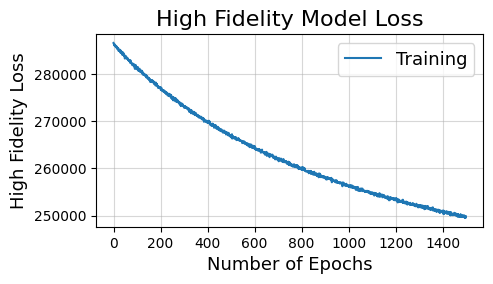

Epochs needed (out of 1500): 1500
HF Training Loss: 249838.84375


In [74]:
plt.figure(figsize=(5,2.5))
plt.plot(HF_losses, label = "Training",lw=1.5)

plt.xlabel('Number of Epochs', fontsize = 13)
plt.ylabel('High Fidelity Loss', fontsize = 13)
plt.title('High Fidelity Model Loss', fontsize = 16)
plt.legend(loc='upper right', fontsize = 13)
plt.grid(which='both', alpha=0.5)
plt.show()

# print(f"Error: {HF_average_percentage_error}")
print(f"Epochs needed (out of {hf_num_epochs}): {len(HF_losses)}")
print(f"HF Training Loss: {HF_loss}")

Multi-Fidelity Model

In [75]:
L1mean = LF_model(X_HF_train.to(device))
L1mean_up= LF_model(X_HF_train.to(device)+embedding)
L1mean_dn = LF_model(X_HF_train.to(device)-embedding)

L2train = torch.hstack((X_HF_train, L1mean, L1mean_up, L1mean_dn)) # think of the house price example (sqr feet, rooms, garden, etc.)
print(L2train.shape)

torch.Size([12, 4])


In [ ]:
MF_input_dim = 4
MF_output_dim = 1

@blitz.utils.variational_estimator
class MultiFidelityNetwork(torch.nn.Module):
  def __init__(self, hidden_dims, MF_input_dim, MF_output_dim):
    super().__init__()
    # Use deterministic (nn.Linear) layers for most of the network to reduce KL burden
    self.fc1 = nn.Linear(MF_input_dim, hidden_dims[0])
    self.bn1 = nn.LayerNorm(hidden_dims[0])
    self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
    self.bn2 = nn.LayerNorm(hidden_dims[1])
    self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
    self.bn3 = nn.LayerNorm(hidden_dims[2])
    self.fc4 = nn.Linear(hidden_dims[2], hidden_dims[3])
    self.bn4 = nn.LayerNorm(hidden_dims[3])
    self.fc5 = nn.Linear(hidden_dims[3], hidden_dims[4])
    self.bn5 = nn.LayerNorm(hidden_dims[4])
    self.fc6 = nn.Linear(hidden_dims[4], hidden_dims[5])
    self.bn6 = nn.LayerNorm(hidden_dims[5])
    # Keep a single Bayesian layer near the top to provide uncertainty while limiting KL
    self.fc7 = blitz.modules.BayesianLinear(hidden_dims[5], hidden_dims[6])
    self.bn7 = nn.LayerNorm(hidden_dims[6])
    # Final output layer deterministic (keeps predictions stable)
    self.fcEND = nn.Linear(hidden_dims[6], MF_output_dim)

  def forward(self, x):
    x = torch.relu(self.bn1(self.fc1(x)))
    x = torch.relu(self.bn2(self.fc2(x)))
    x = torch.relu(self.bn3(self.fc3(x)))
    x = torch.relu(self.bn4(self.fc4(x)))
    x = torch.relu(self.bn5(self.fc5(x)))
    x = torch.relu(self.bn6(self.fc6(x)))
    # Bayesian layer forward
    x = torch.relu(self.bn7(self.fc7(x)))
    x = self.fcEND(x)
    return x

# Use the larger MF_hidden_dims for the Multi-Fidelity model so it has more capacity
MF_model = MultiFidelityNetwork(MF_hidden_dims, MF_input_dim, MF_output_dim).to(device)

for param in MF_model.parameters():
    param.requires_grad = True

In [77]:
HF_model.train()

# Training
MF_losses = [] 
val_losses = []
MF_loss = torch.zeros(1)

# MF_loss criterion and optimizer
criterion = torch.nn.MSELoss().to(device)
optimizer = torch.optim.Adam(MF_model.parameters(), lr=0.0001) # weight_decay=1e-5

for epoch in range(MF_epochs):

    # Training
    MF_loss = MF_model.sample_elbo(inputs=L2train, labels=Y_HF_train, criterion=criterion, sample_nbr=1)
    MF_losses.append(MF_loss.item())
    optimizer.zero_grad()
    MF_loss.backward(retain_graph=True)
    optimizer.step()

    if (epoch+1) % 300 == 0:
        print(f'Epoch [{epoch+1}/{MF_epochs}], Loss: {MF_loss.item():.4f}')

Epoch [300/1600], Loss: 101805.5312
Epoch [600/1600], Loss: 98445.1484
Epoch [600/1600], Loss: 98445.1484
Epoch [900/1600], Loss: 95963.1953
Epoch [900/1600], Loss: 95963.1953
Epoch [1200/1600], Loss: 93967.7109
Epoch [1200/1600], Loss: 93967.7109
Epoch [1500/1600], Loss: 92753.2969
Epoch [1500/1600], Loss: 92753.2969


In [84]:
# Cleanup previous cached tensors and recreate MF_model fresh to avoid autograd graph reuse issues
import gc
to_del = ['preds','preds_hf','preds_MF','preds_LF','pred_mean','hf_mean','y_MF_mean','y_MF_std','y_HF_mean','y_LF_mean']
for name in to_del:
    if name in globals():
        try:
            del globals()[name]
        except Exception:
            pass
gc.collect()
try:
    torch.cuda.empty_cache()
except Exception:
    pass

# Recreate MF model fresh (uses MF_hidden_dims defined earlier)
MF_model = MultiFidelityNetwork(MF_hidden_dims, MF_input_dim, MF_output_dim).to(device)
for param in MF_model.parameters():
    param.requires_grad = True

# Quick MF retrain (safe variant) — use standard forward + MSE loss to avoid sample_elbo autograd complexities
quick_epochs = 200
optimizer = torch.optim.AdamW(MF_model.parameters(), lr=3e-4)
criterion = torch.nn.MSELoss().to(device)

MF_model.train()
short_MF_losses = []
for epoch in range(quick_epochs):
    optimizer.zero_grad()
    preds = MF_model(L2train.to(device))  # single-sample forward from Bayesian layer
    loss = criterion(preds, Y_HF_train.to(device))
    short_MF_losses.append(loss.item())
    loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        print(f'Quick retrain - Epoch [{epoch+1}/{quick_epochs}], Loss: {loss.item():.6f}')

# Move losses into main MF_losses list for plotting compatibility
MF_losses = MF_losses + short_MF_losses
MF_loss = torch.tensor(short_MF_losses[-1])

print('Quick retrain finished.')

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [85]:
# Deterministic MF retrain (no Bayesian layers) — quick test to separate KL effects from predictive performance
class DeterministicMultiFidelityNetwork(torch.nn.Module):
    def __init__(self, hidden_dims, MF_input_dim, MF_output_dim):
        super().__init__()
        self.fc1 = nn.Linear(MF_input_dim, hidden_dims[0])
        self.bn1 = nn.LayerNorm(hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.bn2 = nn.LayerNorm(hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.bn3 = nn.LayerNorm(hidden_dims[2])
        self.fc4 = nn.Linear(hidden_dims[2], hidden_dims[3])
        self.bn4 = nn.LayerNorm(hidden_dims[3])
        self.fc5 = nn.Linear(hidden_dims[3], hidden_dims[4])
        self.bn5 = nn.LayerNorm(hidden_dims[4])
        self.fc6 = nn.Linear(hidden_dims[4], hidden_dims[5])
        self.bn6 = nn.LayerNorm(hidden_dims[5])
        self.fc7 = nn.Linear(hidden_dims[5], hidden_dims[6])
        self.bn7 = nn.LayerNorm(hidden_dims[6])
        self.fcEND = nn.Linear(hidden_dims[6], MF_output_dim)
    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        x = torch.relu(self.bn3(self.fc3(x)))
        x = torch.relu(self.bn4(self.fc4(x)))
        x = torch.relu(self.bn5(self.fc5(x)))
        x = torch.relu(self.bn6(self.fc6(x)))
        x = torch.relu(self.bn7(self.fc7(x)))
        x = self.fcEND(x)
        return x

# Instantiate deterministic MF model and train quickly
det_MF_model = DeterministicMultiFidelityNetwork(MF_hidden_dims, MF_input_dim, MF_output_dim).to(device)
optimizer = torch.optim.AdamW(det_MF_model.parameters(), lr=3e-4)
criterion = torch.nn.MSELoss().to(device)
det_MF_model.train()
det_losses = []
for epoch in range(200):
    optimizer.zero_grad()
    preds = det_MF_model(L2train.to(device))
    loss = criterion(preds, Y_HF_train.to(device))
    det_losses.append(loss.item())
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f'Det MF retrain - Epoch [{epoch+1}/200] Loss: {loss.item():.6f}')

# Evaluate predictive MSE
det_MF_model.eval()
with torch.no_grad():
    preds = det_MF_model(L2train.to(device))
    det_mse_train = torch.mean((preds - Y_HF_train.to(device))**2).item()

print(f'Deterministic MF training MSE: {det_mse_train:.6f}')

# Save det_losses into a separate variable for plotting
det_MF_losses = det_losses

# Plot comparison quick
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.plot(det_MF_losses, label='Det MF MSE loss')
if len(MF_losses)>0:
    plt.plot(MF_losses[-len(det_MF_losses):], label='BNN MF ELBO (recent)')
plt.legend()
plt.title('Deterministic MF vs recent MF losses')
plt.grid(alpha=0.4)
plt.show()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

MF Training Loss: 92270.71875


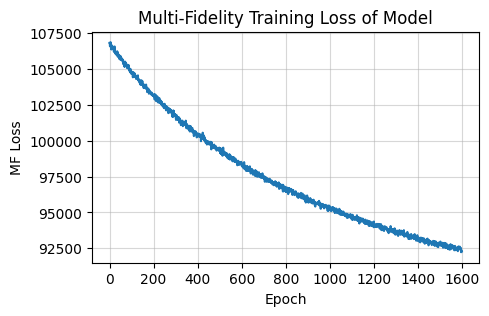

In [78]:
plt.figure(figsize=(5,3))
plt.plot(MF_losses)
plt.xlabel('Epoch')
plt.ylabel('MF Loss')
plt.title('Multi-Fidelity Training Loss of Model')
plt.grid(which='both', alpha=0.5)
print(f"MF Training Loss: {MF_loss}")

plt.show()

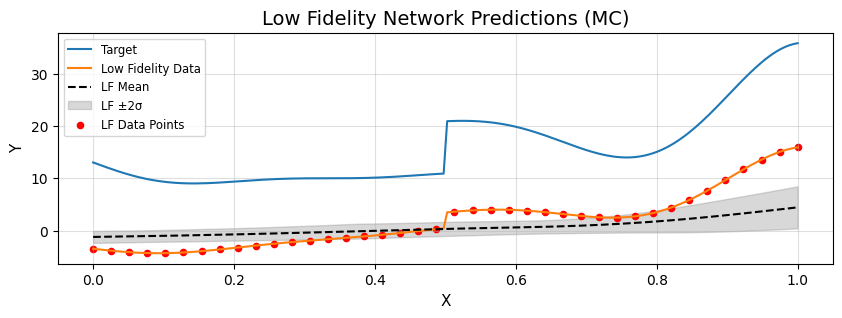

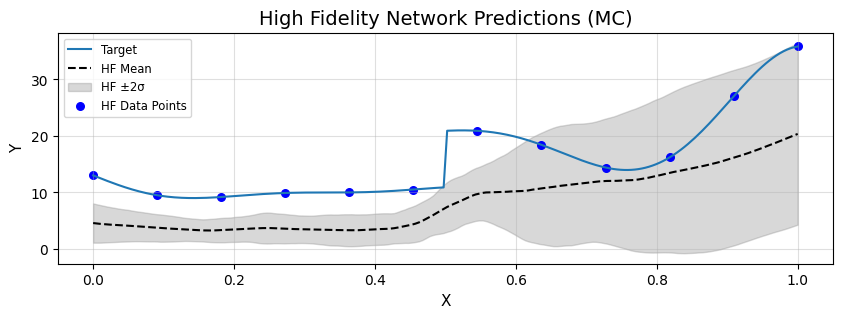

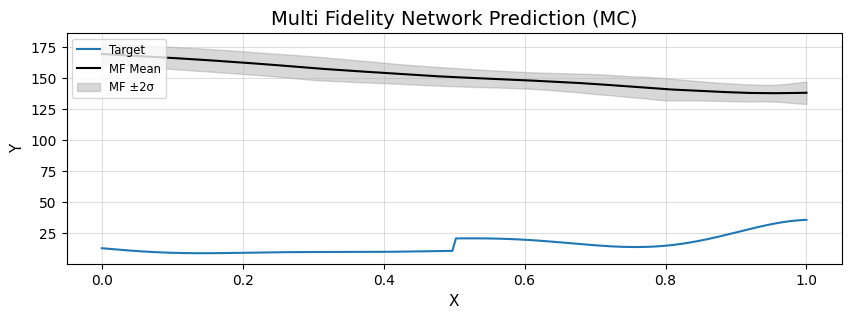

LF Training Loss: 212993.703125
HF Training Loss: 249838.84375
MF Training Loss: 92270.71875
Finished in 27.864444255828857 seconds.


In [79]:
# Put models
LF_model.eval()
HF_model.eval()
MF_model.eval()

mc_samples = 20  # number of MC forward passes for uncertainty estimation
Zc = Z.to(device)

# Define the NEW input data and perform Monte Carlo sampling
with torch.no_grad():
    # LF predictions (MC)
    preds_LF = torch.stack([LF_model(Zc) for _ in range(mc_samples)], dim=0)  # [mc, N, 1]
    y_LF_mean = preds_LF.mean(dim=0)
    y_LF_std = preds_LF.std(dim=0)

    # HF predictions (MC)
    preds_HF = torch.stack([HF_model(Zc) for _ in range(mc_samples)], dim=0)
    y_HF_mean = preds_HF.mean(dim=0)
    y_HF_std = preds_HF.std(dim=0)

    # MF predictions depend on LF outputs — construct per-sample L2test and run MF
    preds_MF = []
    for s in range(mc_samples):
        lf_s = preds_LF[s]
        L2test = torch.hstack((Zc, lf_s, lf_s + embedding, lf_s - embedding))
        preds_MF.append(MF_model(L2test))
    preds_MF = torch.stack(preds_MF, dim=0)
    y_MF_mean = preds_MF.mean(dim=0)
    y_MF_std = preds_MF.std(dim=0)

# Convert to cpu numpy for plotting
Z_np = Zc.cpu().numpy()
HF_target = HF(Z).cpu().numpy()
LF_target = LF(Z).cpu().numpy()

y_LF_mean_np = y_LF_mean.cpu().numpy()
y_LF_std_np = y_LF_std.cpu().numpy()

y_HF_mean_np = y_HF_mean.cpu().numpy()
y_HF_std_np = y_HF_std.cpu().numpy()

y_MF_mean_np = y_MF_mean.cpu().numpy()
y_MF_std_np = y_MF_std.cpu().numpy()

# Plot LF predictions with uncertainty
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(Z, HF(Z), label= "Target ")
ax.plot(Z, LF(Z), label= "Low Fidelity Data")
ax.plot(Z_np, y_LF_mean_np, '--k', lw=1.5, label='LF Mean')
ax.fill_between(Z_np.flatten(), (y_LF_mean_np - 2*y_LF_std_np).flatten(), (y_LF_mean_np + 2*y_LF_std_np).flatten(), color='gray', alpha=0.3, label='LF ±2σ')
ax.scatter(X_LF_train.cpu().detach().numpy(), Y_LF_train.cpu().detach().numpy(), c='r', s=20, label='LF Data Points')
ax.set_xlabel('X', fontsize=11)
ax.set_ylabel('Y', fontsize=11)
ax.set_title('Low Fidelity Network Predictions (MC)', fontsize=14)
ax.legend(loc='upper left', fontsize='small')
ax.grid(which='both', alpha=0.4)
plt.show()

# Plot HF predictions with uncertainty
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(Z, HF(Z), label= "Target ")
ax.plot(Z_np, y_HF_mean_np, '--k', lw=1.5, label='HF Mean')
ax.fill_between(Z_np.flatten(), (y_HF_mean_np - 2*y_HF_std_np).flatten(), (y_HF_mean_np + 2*y_HF_std_np).flatten(), color='gray', alpha=0.3, label='HF ±2σ')
ax.scatter(X_HF_train.cpu().detach().numpy(), Y_HF_train.cpu().detach().numpy(), c='b', s=30, label='HF Data Points')
ax.set_xlabel('X', fontsize=11)
ax.set_ylabel('Y', fontsize=11)
ax.set_title('High Fidelity Network Predictions (MC)', fontsize=14)
ax.legend(loc='upper left', fontsize='small')
ax.grid(which='both', alpha=0.4)
plt.show()

# Plot MF predictions with uncertainty
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(Z, HF(Z), label= "Target")
ax.plot(Z_np, y_MF_mean_np, 'k', lw=1.5, label='MF Mean')
ax.fill_between(Z_np.flatten(), (y_MF_mean_np - 2*y_MF_std_np).flatten(), (y_MF_mean_np + 2*y_MF_std_np).flatten(), color='gray', alpha=0.3, label='MF ±2σ')
ax.set_xlabel('X', fontsize=11)
ax.set_ylabel('Y', fontsize=11)
ax.set_title('Multi Fidelity Network Prediction (MC)', fontsize=14)
ax.legend(loc='upper left', fontsize='small')
ax.grid(which='both', alpha=0.4)
plt.show()

print(f"LF Training Loss: {LF_loss}")
print(f"HF Training Loss: {HF_loss}")
print(f"MF Training Loss: {MF_loss}")

print(f"Finished in {(time.time() - time_start)} seconds." )

Device: cpu
MF sample_elbo (last stored MF_loss): 92270.718750
MF predictive MSE on training data (MC mean): 49.298481
HF predictive MSE on HF training data (MC mean): 64.032562
Params -> LF: 245004, HF: 245004, MF: 206851


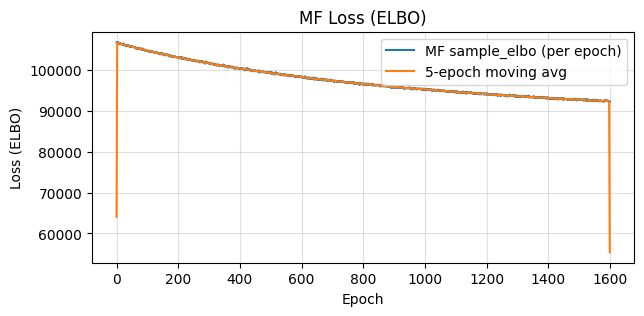

In [80]:
# Diagnostic cell: ELBO vs predictive MSE and MF loss trend
import numpy as np
import matplotlib.pyplot as plt

print(f"Device: {device}")

# Ensure required variables exist
_required = ['MF_model','MF_losses','MF_loss','L2train','Y_HF_train','HF_model','X_HF_train']
missing = [v for v in _required if v not in globals()]
if missing:
    print('Missing variables, cannot run diagnostic:', missing)
else:
    mc_samples = 20
    MF_model.eval(); HF_model.eval()
    with torch.no_grad():
        preds = torch.stack([MF_model(L2train) for _ in range(mc_samples)], dim=0)  # [mc, N, 1]
        pred_mean = preds.mean(dim=0)
        mse_train = torch.mean((pred_mean - Y_HF_train)**2).item()

        preds_hf = torch.stack([HF_model(X_HF_train.to(device)) for _ in range(mc_samples)], dim=0)
        hf_mean = preds_hf.mean(dim=0)
        hf_mse = torch.mean((hf_mean - Y_HF_train)**2).item()

    def count_params(m):
        return sum(p.numel() for p in m.parameters() if p.requires_grad)

    print(f"MF sample_elbo (last stored MF_loss): {MF_loss.item():.6f}")
    print(f"MF predictive MSE on training data (MC mean): {mse_train:.6f}")
    print(f"HF predictive MSE on HF training data (MC mean): {hf_mse:.6f}")
    print("Params -> LF: {}, HF: {}, MF: {}".format(count_params(LF_model), count_params(HF_model), count_params(MF_model)))

    # Plot MF loss curve with a 5-epoch moving average (if available)
    arr = np.array(MF_losses)
    if arr.size == 0:
        print('MF_losses array is empty — MF training may not have run yet.')
    else:
        window = 5
        smooth = np.convolve(arr, np.ones(window)/window, mode='same')
        plt.figure(figsize=(7,3))
        plt.plot(arr, label='MF sample_elbo (per epoch)')
        plt.plot(smooth, label=f'{window}-epoch moving avg', linewidth=1.5)
        plt.xlabel('Epoch')
        plt.ylabel('Loss (ELBO)')
        plt.title('MF Loss (ELBO)')
        plt.legend()
        plt.grid(alpha=0.4)
        plt.show()